# Análisis Exploratorio de Datos - Olist

Este notebook contiene el análisis exploratorio de los datos de Olist
previamente auditados y preparados.

El objetivo es identificar patrones y hallazgos relacionados con:

- ventas y pedidos;
- productos y categorías;
- clientes;
- comportamiento de compra;
- logística;
- satisfacción del cliente;
- recurrencia.

Las transformaciones de calidad y construcción de las tablas analíticas
se realizaron previamente en el notebook de auditoría y preparación.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
orders = pd.read_parquet(
    "../data/processed/orders_analysis.parquet"
)

items = pd.read_parquet(
    "../data/processed/order_items_analysis.parquet"
)

customers = pd.read_parquet(
    "../data/processed/customer_analysis.parquet"
)

## 1. Panorama general del negocio

### ¿Cuál es el volumen general de operaciones de Olist?

Como primera aproximación al negocio se analizan los principales indicadores generales del dataset:

- cantidad total de pedidos;
- pedidos efectivamente entregados;
- clientes únicos;
- valor total pagado;
- ticket promedio;
- cantidad de ítems vendidos;
- valor de productos;
- costo total de flete.

Para las métricas económicas se consideran principalmente los pedidos con estado `delivered`, ya que representan operaciones cuyo flujo comercial fue completado.

Se distingue entre `products_value`, que representa el valor de los productos vendidos, `freight_value`, correspondiente al costo de envío, y `payment_value`, que representa el monto registrado como pago del pedido.

In [5]:
delivered_orders = orders[
    orders["order_status"] == "delivered"
].copy()

total_orders = orders["order_id"].nunique()

delivered_orders_count = delivered_orders["order_id"].nunique()

unique_customers = orders["customer_unique_id"].nunique()

total_revenue = delivered_orders["payment_value"].sum()

average_ticket = delivered_orders["payment_value"].mean()

items_sold = delivered_orders["items_count"].sum()

products_value = delivered_orders["products_value"].sum()

total_freight = delivered_orders["freight_value"].sum()

print("Pedidos totales:", total_orders)
print("Pedidos entregados:", delivered_orders_count)
print("Clientes únicos:", unique_customers)
print("Facturación total:", round(total_revenue, 2))
print("Ticket promedio:", round(average_ticket, 2))
print("Ítems vendidos:", int(items_sold))
print("Valor de productos:", round(products_value, 2))
print("Flete total:", round(total_freight, 2))

delivery_rate = (
    delivered_orders_count
    / total_orders
    * 100
)

print(
    "Porcentaje de pedidos entregados:",
    round(delivery_rate, 2),
    "%"
)

order_status_distribution = (
    orders["order_status"]
    .value_counts()
)

print("Distribución de estados de pedidos:")
print(order_status_distribution)

order_status_percentage = (
    orders["order_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Porcentaje de estados de pedidos:")
order_status_percentage

Pedidos totales: 99441
Pedidos entregados: 96478
Clientes únicos: 96096
Facturación total: 15422461.77
Ticket promedio: 159.86
Ítems vendidos: 110197
Valor de productos: 13221498.11
Flete total: 2198275.64
Porcentaje de pedidos entregados: 97.02 %
Distribución de estados de pedidos:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64
Porcentaje de estados de pedidos:


order_status
delivered      97.02
shipped         1.11
canceled        0.63
unavailable     0.61
invoiced        0.32
processing      0.30
created         0.01
approved        0.00
Name: proportion, dtype: float64

### Hallazgos generales

El dataset contiene 99.441 pedidos, de los cuales 96.478 fueron entregados, lo que representa aproximadamente el 97,02% del total.

Para los pedidos entregados, el valor total registrado en pagos asciende a 15.422.461,77, con un ticket promedio de 159,86 por pedido.

En total se vendieron 110.197 ítems asociados a pedidos entregados, lo que representa aproximadamente 1,14 ítems por pedido.

El valor de los productos vendidos asciende a 13.221.498,11, mientras que el costo total de flete alcanza 2.198.275,64. El flete representa aproximadamente el 14,25% del valor total pagado.

La elevada proporción de pedidos entregados indica que la gran mayoría de las órdenes registradas completó el flujo comercial. Los restantes estados representan una proporción reducida del total y serán considerados separadamente cuando sea necesario.

## 2. Evolución temporal de pedidos y ventas

### ¿Cómo evolucionaron los pedidos y el valor pagado a lo largo del tiempo?

Se analiza la evolución mensual de los pedidos entregados para identificar tendencias, períodos de crecimiento, caídas y meses con mayor volumen de actividad.

Se consideran pedidos con estado `delivered`, manteniendo el mismo criterio utilizado para las métricas económicas generales.

Para cada mes se calculan:

- cantidad de pedidos entregados;
- valor total pagado;
- ticket promedio.

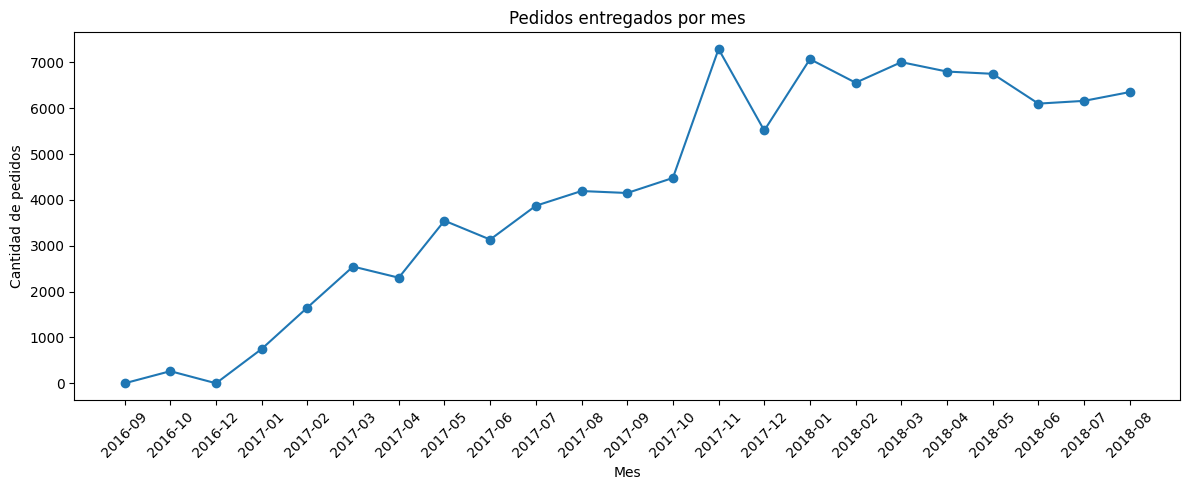

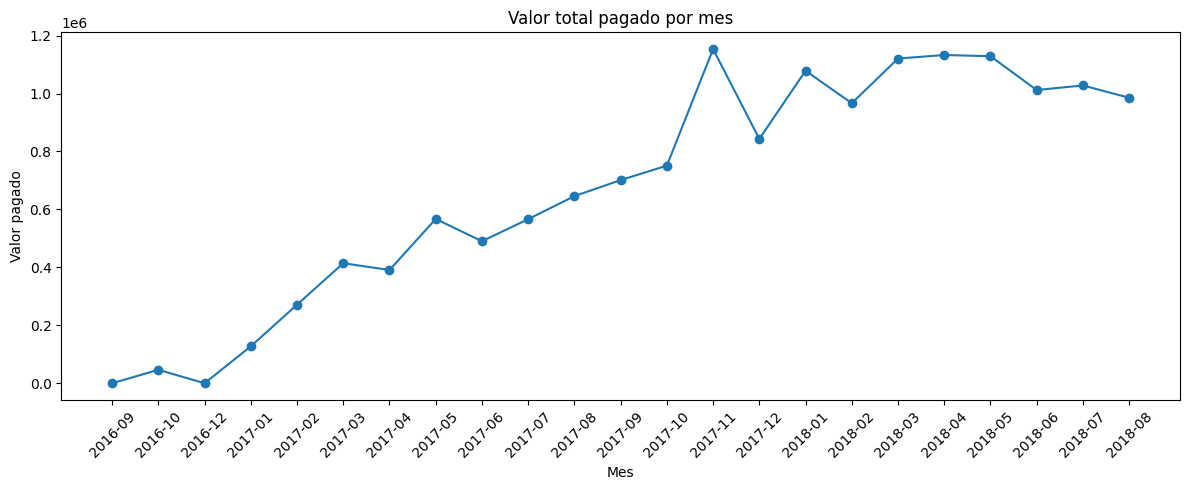

Mes con más pedidos:
order_purchase_timestamp       2017-11
orders                            7289
total_payment               1153528.05
average_ticket              158.256009
month                          2017-11
Name: 13, dtype: object

Mes con mayor valor pagado:
order_purchase_timestamp       2017-11
orders                            7289
total_payment               1153528.05
average_ticket              158.256009
month                          2017-11
Name: 13, dtype: object


,orders,total_payment
orders,1.000000,0.996168
total_payment,0.996168,1.000000


In [16]:
monthly_sales = (
    delivered_orders
    .groupby(
        delivered_orders["order_purchase_timestamp"].dt.to_period("M")
    )
    .agg(
        orders=("order_id", "nunique"),
        total_payment=("payment_value", "sum"),
        average_ticket=("payment_value", "mean")
    )
    .reset_index()
)

monthly_sales

monthly_sales["month"] = (
    monthly_sales["order_purchase_timestamp"].astype(str)
)

monthly_sales[
    [
        "month",
        "orders",
        "total_payment",
        "average_ticket"
    ]
]

monthly_sales.sort_values(
    "orders",
    ascending=False
).head(10)

monthly_sales.sort_values(
    "total_payment",
    ascending=False
).head(10)

monthly_sales.head()
monthly_sales.tail()

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales["month"],
    monthly_sales["orders"],
    marker="o"
)

plt.title("Pedidos entregados por mes")
plt.xlabel("Mes")
plt.ylabel("Cantidad de pedidos")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales["month"],
    monthly_sales["total_payment"],
    marker="o"
)

plt.title("Valor total pagado por mes")
plt.xlabel("Mes")
plt.ylabel("Valor pagado")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# print("Primer mes:")
# print(monthly_sales.iloc[0])

# print("\nÚltimo mes:")
# print(monthly_sales.iloc[-1])

peak_orders = monthly_sales.loc[
    monthly_sales["orders"].idxmax()
]

peak_payment = monthly_sales.loc[
    monthly_sales["total_payment"].idxmax()
]

print("Mes con más pedidos:")
print(peak_orders)

print("\nMes con mayor valor pagado:")
print(peak_payment)

monthly_sales[
    ["orders", "total_payment"]
].corr()

### Hallazgos de la evolución temporal

La evolución mensual muestra un crecimiento sostenido de la actividad durante 2017, tanto en cantidad de pedidos entregados como en valor total pagado.

Ambas métricas presentan trayectorias muy similares, lo que sugiere que el crecimiento del valor pagado estuvo principalmente asociado al aumento del volumen de pedidos.

Hacia finales de 2017 se observa un fuerte incremento de actividad, seguido por una caída temporal en diciembre y una recuperación durante los primeros meses de 2018.

Durante 2018, el volumen se mantiene en niveles elevados pero relativamente estables, generalmente entre aproximadamente 6.000 y 7.000 pedidos mensuales, con una moderada disminución hacia los últimos meses observados.

Los primeros registros de 2016 presentan un volumen muy reducido y no se consideran representativos para evaluar tendencias de crecimiento. En particular, septiembre de 2016 contiene un único pedido entregado sin información de pago asociada, anomalía previamente identificada durante la auditoría de calidad de datos.

### Hallazgo

La cantidad mensual de pedidos entregados presenta una correlación de aproximadamente 0,996 con el valor total pagado mensual, lo que evidencia una relación positiva extremadamente fuerte entre ambas métricas.

El máximo de ambas series ocurre en noviembre de 2017, con 7.289 pedidos entregados y un valor total pagado de 1.153.528,05. El ticket promedio de ese mes fue de 158,26.

Esto indica que los períodos con mayor volumen de pedidos también concentran los mayores valores pagados. No obstante, la correlación no implica causalidad y será complementada con el análisis de la evolución del ticket promedio.

## 3. Análisis de categorías de productos

### ¿Qué categorías generan mayor valor y cuáles venden más ítems?

En este bloque se analiza el desempeño de las categorías de productos considerando únicamente pedidos con estado `delivered`.

El objetivo es identificar si las categorías que concentran mayor volumen de ventas en cantidad de ítems son también las que generan mayor valor económico.

Para cada categoría se calcularán las siguientes métricas:

- cantidad de ítems vendidos;
- cantidad de pedidos asociados;
- cantidad de productos distintos;
- valor total de productos vendidos;
- valor total de flete;
- precio promedio por ítem.

Este análisis permitirá distinguir categorías de alto volumen de aquellas que, aun con menor cantidad de unidades vendidas, generan un mayor valor económico.

Top 10 categorías por facturación:             category_name  items_sold  orders  products  product_revenue  \
43          health_beauty        9465    8647      2397       1233131.72   
72          watches_gifts        5859    5495      1300       1166176.98   
7          bed_bath_table       10953    9272      2991       1023434.76   
67         sports_leisure        8431    7530      2822        954852.55   
15  computers_accessories        7644    6530      1600        888724.61   
39        furniture_decor        8160    6307      2593        711927.69   
49             housewares        6795    5743      2282        615628.69   
20             cool_stuff        3718    3559       770        610204.10   
5                    auto        4140    3810      1853        578966.65   
71                   toys        4030    3804      1373        471286.48   

    freight_value  average_price  
43      178957.81     130.283330  
72       98156.14     199.040276  
7       201774.50      

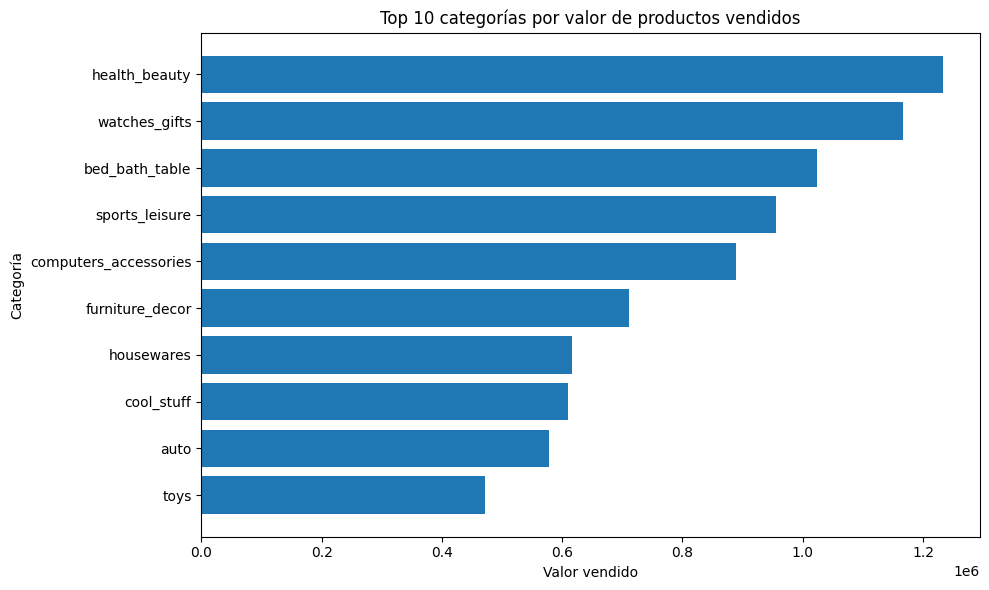

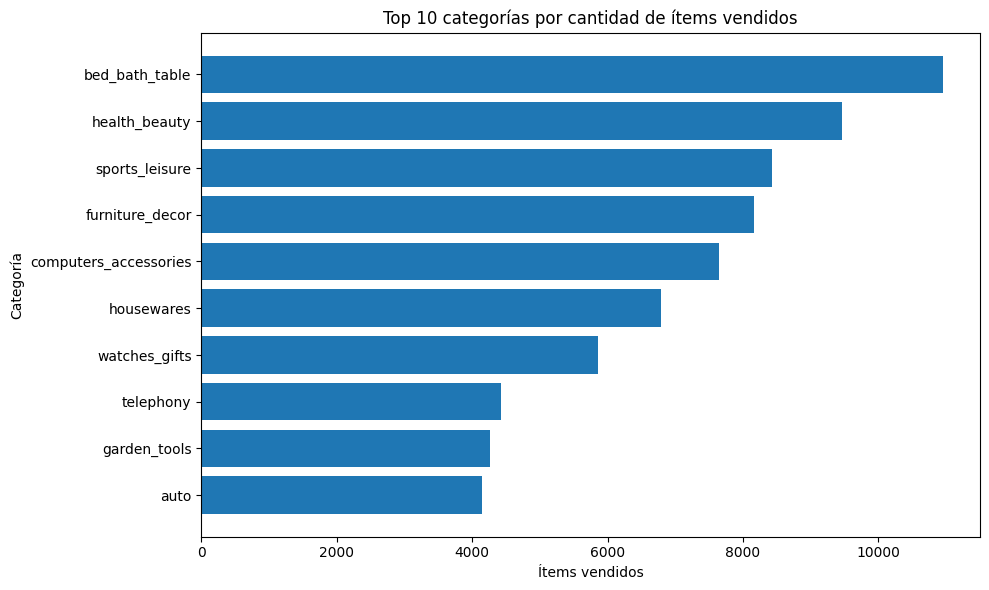

In [19]:
delivered_items = items[
    items["order_status"] == "delivered"
].copy()

category_analysis = (
    delivered_items
    .groupby("category_name")
    .agg(
        items_sold=("order_item_id", "count"),
        orders=("order_id", "nunique"),
        products=("product_id", "nunique"),
        product_revenue=("price", "sum"),
        freight_value=("freight_value", "sum"),
        average_price=("price", "mean")
    )
    .reset_index()
)

top_categories_revenue = (
    category_analysis
    .sort_values("product_revenue", ascending=False)
    .head(10)
)

print("Top 10 categorías por facturación:", top_categories_revenue)


top_categories_items = (
    category_analysis
    .sort_values("items_sold", ascending=False)
    .head(10)
)

print("Top 10 categorías por cantidad de artículos vendidos:", top_categories_items)

plt.figure(figsize=(10, 6))

plt.barh(
    top_categories_revenue["category_name"],
    top_categories_revenue["product_revenue"]
)

plt.title("Top 10 categorías por valor de productos vendidos")
plt.xlabel("Valor vendido")
plt.ylabel("Categoría")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

plt.figure(figsize=(10, 6))

plt.barh(
    top_categories_items["category_name"],
    top_categories_items["items_sold"]
)

plt.title("Top 10 categorías por cantidad de ítems vendidos")
plt.xlabel("Ítems vendidos")
plt.ylabel("Categoría")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()


### Hallazgos por categoría

El análisis muestra que las categorías con mayor volumen de artículos vendidos no coinciden necesariamente con aquellas que generan mayor valor económico.

`bed_bath_table` lidera en volumen con 10.953 ítems vendidos, pero ocupa el tercer lugar por valor de productos vendidos, con aproximadamente 1,02 millones.

`health_beauty` ocupa el segundo lugar en volumen, con 9.465 ítems, pero lidera el valor vendido con aproximadamente 1,23 millones.

Por su parte, `watches_gifts` presenta un comportamiento particularmente relevante: con 5.859 ítems vendidos se posiciona segunda en valor económico, alcanzando aproximadamente 1,17 millones. Esto se relaciona con su elevado precio promedio, cercano a 199 por ítem.

En sentido contrario, categorías como `telephony` presentan un volumen considerable de ventas pero un menor valor económico por unidad.

Estos resultados muestran que el desempeño de una categoría debe analizarse considerando conjuntamente el volumen vendido y el valor generado, ya que un alto número de unidades no implica necesariamente una mayor contribución económica.

## 4. Distribución geográfica de clientes y ventas

### ¿En qué estados se concentran los clientes, los pedidos y el valor pagado?

En este bloque se analiza la distribución geográfica de la actividad comercial de Olist a nivel de estado del cliente.

El objetivo es identificar:

- los estados con mayor cantidad de clientes;
- los estados con mayor cantidad de pedidos entregados;
- los estados que concentran el mayor valor total pagado;
- posibles diferencias en el ticket promedio entre regiones.

Para mantener consistencia con los análisis económicos anteriores, se consideran únicamente pedidos con estado `delivered`.

Este análisis permitirá determinar si la actividad de Olist se encuentra geográficamente concentrada y si los estados con mayor cantidad de pedidos son también aquellos que generan mayor valor económico.

Análisis por estado:    customer_state  customers  orders  total_payment  average_ticket
0              AC         76      80       19586.25      244.828125
1              AL        387     397       94195.79      237.268992
2              AM        140     145       27596.18      190.318483
3              AP         66      67       16141.81      240.922537
4              BA       3158    3256      591270.60      181.594165
5              CE       1258    1279      266463.97      208.337740
6              DF       2019    2080      346146.17      166.416428
7              ES       1928    1995      317682.65      159.239424
8              GO       1895    1957      334294.22      170.819734
9              MA        700     717      147807.29      206.146848
10             MG      11001   11354     1819277.61      160.232307
11             MS        681     701      134421.54      191.756833
12             MT        856     886      181441.72      204.787494
13             PA        92

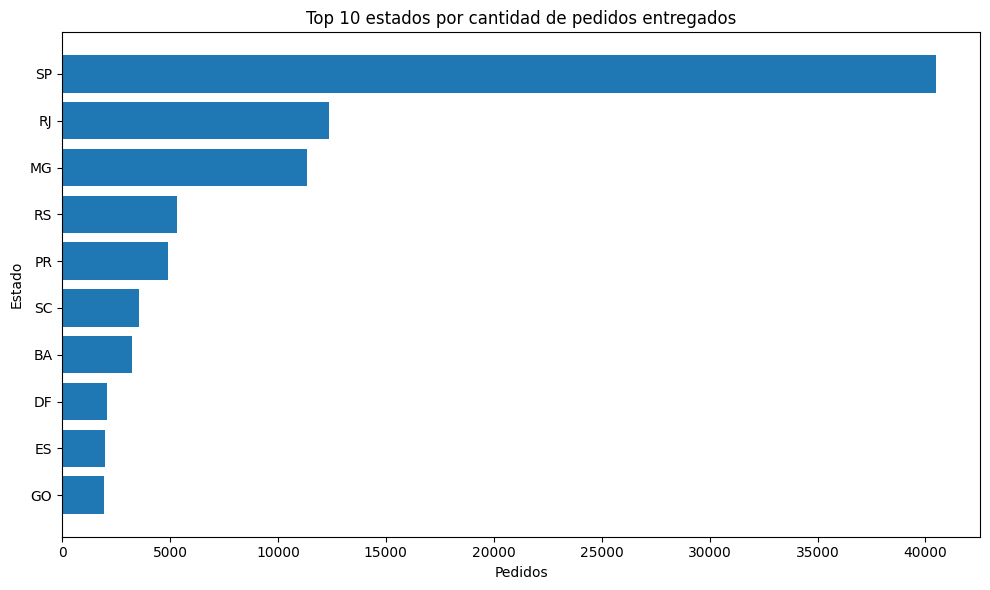

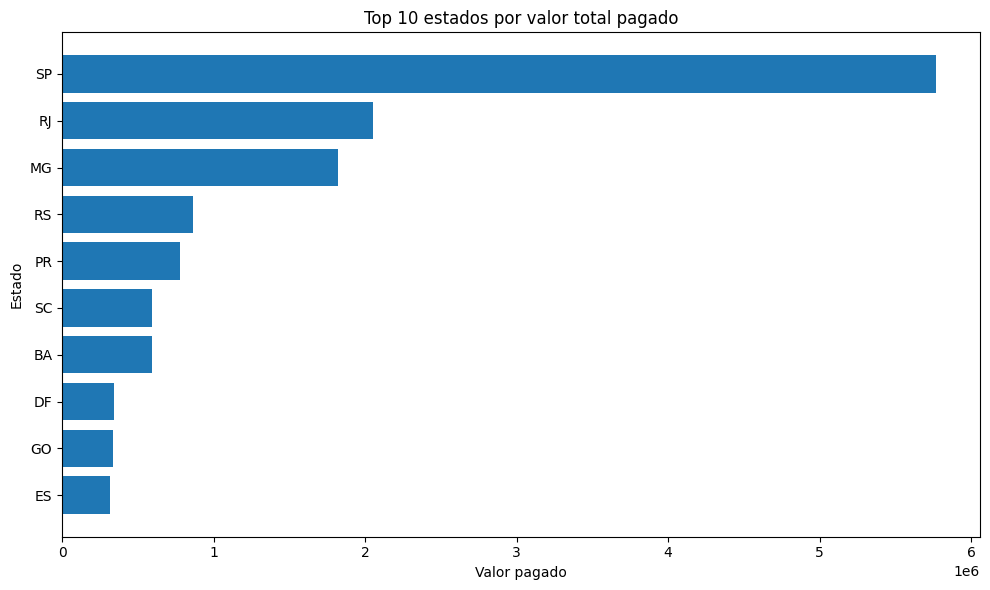

In [22]:
state_analysis = (
    delivered_orders
    .groupby("customer_state")
    .agg(
        customers=("customer_unique_id", "nunique"),
        orders=("order_id", "nunique"),
        total_payment=("payment_value", "sum"),
        average_ticket=("payment_value", "mean")
    )
    .reset_index()
)

print("Análisis por estado:", state_analysis)

top_states_customers = (
    state_analysis
    .sort_values("customers", ascending=False)
    .head(10)
)

print("Top 10 estados por cantidad de clientes:", top_states_customers)

top_states_payment = (
    state_analysis
    .sort_values("total_payment", ascending=False)
    .head(10)
)

print("Top 10 estados por valor total pagado:", top_states_payment)

state_analysis["payment_share_pct"] = (
    state_analysis["total_payment"]
    / state_analysis["total_payment"].sum()
    * 100
)

state_analysis["orders_share_pct"] = (
    state_analysis["orders"]
    / state_analysis["orders"].sum()
    * 100
)

state_analysis[
    [
        "customer_state",
        "customers",
        "orders",
        "total_payment",
        "average_ticket",
        "payment_share_pct",
        "orders_share_pct"
    ]
].sort_values(
    "total_payment",
    ascending=False
).head(10)

sp = state_analysis[
    state_analysis["customer_state"] == "SP"
]

sp

top_states_orders = (
    state_analysis
    .sort_values("orders", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_states_orders["customer_state"],
    top_states_orders["orders"]
)

plt.title("Top 10 estados por cantidad de pedidos entregados")
plt.xlabel("Pedidos")
plt.ylabel("Estado")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()


top_states_payment = (
    state_analysis
    .sort_values("total_payment", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_states_payment["customer_state"],
    top_states_payment["total_payment"]
)

plt.title("Top 10 estados por valor total pagado")
plt.xlabel("Valor pagado")
plt.ylabel("Estado")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

### Hallazgos geográficos

La actividad comercial presenta una fuerte concentración geográfica.

São Paulo (`SP`) constituye el principal mercado de Olist, con 40.501 pedidos entregados y 39.156 clientes únicos. Esto representa aproximadamente el 41,98% de todos los pedidos entregados analizados.

Sin embargo, SP concentra aproximadamente el 37,41% del valor total pagado, una proporción inferior a su participación en pedidos. Su ticket promedio es de aproximadamente 142,48, por debajo del ticket promedio general de 159,86.

Esto indica que el liderazgo de São Paulo se explica principalmente por su elevado volumen de operaciones y no por un mayor valor promedio por pedido.

Rio de Janeiro (`RJ`) y Minas Gerais (`MG`) ocupan el segundo y tercer lugar tanto en cantidad de clientes como en valor total pagado.

En conjunto, SP, RJ y MG concentran aproximadamente dos tercios de los pedidos entregados y más del 60% del valor pagado, evidenciando una importante concentración regional de la actividad.

Algunos estados de menor volumen presentan tickets promedio elevados. Sin embargo, estas diferencias deben interpretarse con cautela debido a la menor cantidad de pedidos observados en dichos estados.

## 5. Análisis de logística y cumplimiento de entregas

### ¿Cuánto tardan los pedidos en llegar y qué proporción se entrega después de la fecha estimada?

En este bloque se analiza el desempeño logístico de Olist a partir de los pedidos efectivamente entregados.

El objetivo es evaluar:

- el tiempo promedio y mediano de entrega;
- la distribución de los tiempos de entrega;
- la cantidad y proporción de pedidos entregados después de la fecha estimada;
- la magnitud de los retrasos en aquellos pedidos que llegaron tarde.

Para este análisis se utilizan `delivery_time_days`, que representa el tiempo transcurrido entre la compra y la entrega al cliente, y `delivery_delay_days`, que compara la fecha real de entrega con la fecha estimada.

Un valor positivo de `delivery_delay_days` indica una entrega posterior a la fecha estimada, mientras que un valor negativo indica que el pedido llegó antes de lo previsto.

Se excluyen de estos cálculos los pedidos sin fecha real de entrega, ya que no es posible determinar su duración ni el cumplimiento de la fecha estimada.

Pedidos entregados: 96478
Pedidos válidos para análisis logístico: 96470
Distribución de tiempos de entrega: count    96470.000000
mean        12.558217
std          9.546156
min          0.533414
25%          6.766204
50%         10.217477
75%         15.720182
max        209.628611
Name: delivery_time_days, dtype: float64
Distribución de retrasos en la entrega: count    96470.000000
mean       -11.178126
std         10.184354
min       -146.016123
25%        -16.244065
50%        -11.948102
75%         -6.389815
max        188.975081
Name: delivery_delay_days, dtype: float64
Tiempo promedio de entrega: 12.56 días
Mediana del tiempo de entrega: 10.22 días
Pedidos entregados tarde: 7826
Porcentaje entregado tarde: 8.11 %
Porcentaje entregado en fecha o antes: 91.89 %
Distribución de retrasos en la entrega de pedidos tardíos: count    7826.000000
mean        9.551776
std        13.952540
min         0.002500
25%         1.867179
50%         5.806481
75%        11.820978
max       188.97

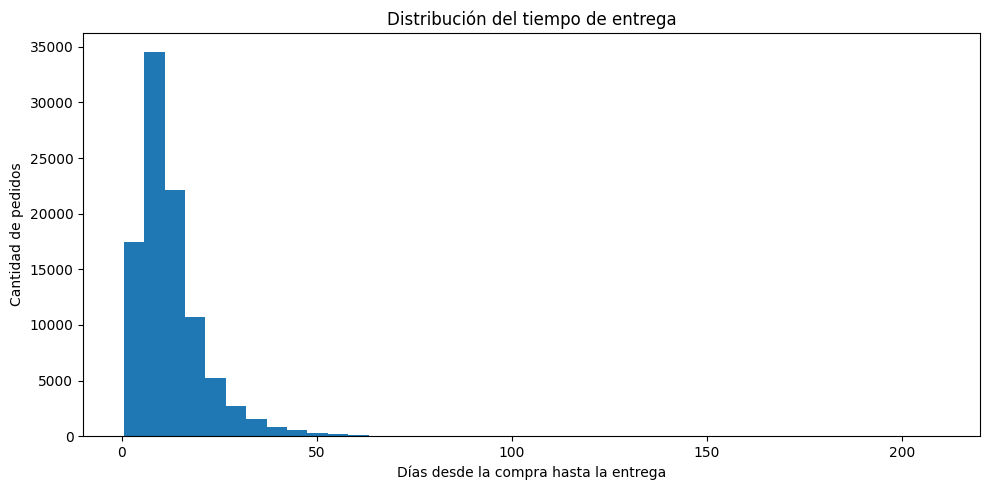

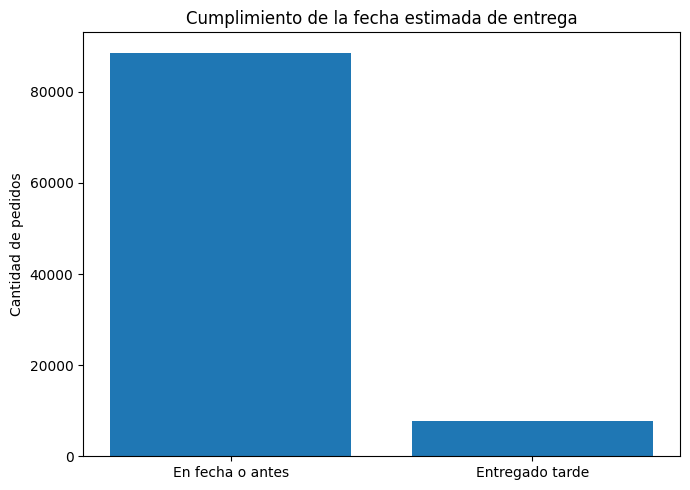

In [24]:
delivery_analysis = delivered_orders[
    delivered_orders["delivery_time_days"].notna()
    & delivered_orders["delivery_delay_days"].notna()
].copy()

print("Pedidos entregados:", delivered_orders.shape[0])
print("Pedidos válidos para análisis logístico:", delivery_analysis.shape[0])

print("Distribución de tiempos de entrega:",delivery_analysis["delivery_time_days"].describe())
print("Distribución de retrasos en la entrega:",delivery_analysis["delivery_delay_days"].describe())

average_delivery_time = (
    delivery_analysis["delivery_time_days"].mean()
)

median_delivery_time = (
    delivery_analysis["delivery_time_days"].median()
)

print(
    "Tiempo promedio de entrega:",
    round(average_delivery_time, 2),
    "días"
)

print(
    "Mediana del tiempo de entrega:",
    round(median_delivery_time, 2),
    "días"
)

late_orders = delivery_analysis[
    delivery_analysis["delivery_delay_days"] > 0
]

on_time_orders = delivery_analysis[
    delivery_analysis["delivery_delay_days"] <= 0
]

late_percentage = (
    late_orders.shape[0]
    / delivery_analysis.shape[0]
    * 100
)

on_time_percentage = (
    on_time_orders.shape[0]
    / delivery_analysis.shape[0]
    * 100
)

print("Pedidos entregados tarde:", late_orders.shape[0])

print(
    "Porcentaje entregado tarde:",
    round(late_percentage, 2),
    "%"
)

print(
    "Porcentaje entregado en fecha o antes:",
    round(on_time_percentage, 2),
    "%"
)

print("Distribución de retrasos en la entrega de pedidos tardíos:", late_orders["delivery_delay_days"].describe())
print(
    "Retraso promedio:",
    round(late_orders["delivery_delay_days"].mean(), 2),
    "días"
)

print(
    "Mediana del retraso:",
    round(late_orders["delivery_delay_days"].median(), 2),
    "días"
)

print(
    "Mayor retraso:",
    round(late_orders["delivery_delay_days"].max(), 2),
    "días"
)

plt.figure(figsize=(10, 5))

plt.hist(
    delivery_analysis["delivery_time_days"],
    bins=40
)

plt.title("Distribución del tiempo de entrega")
plt.xlabel("Días desde la compra hasta la entrega")
plt.ylabel("Cantidad de pedidos")

plt.tight_layout()
plt.show()


delivery_performance = pd.Series({
    "En fecha o antes": on_time_orders.shape[0],
    "Entregado tarde": late_orders.shape[0]
})

plt.figure(figsize=(7, 5))

plt.bar(
    delivery_performance.index,
    delivery_performance.values
)

plt.title("Cumplimiento de la fecha estimada de entrega")
plt.ylabel("Cantidad de pedidos")

plt.tight_layout()
plt.show()

### Hallazgos logísticos

De los 96.478 pedidos registrados como `delivered`, 96.470 cuentan con la información temporal necesaria para analizar el proceso de entrega. Los 8 casos restantes corresponden a pedidos entregados sin fecha de entrega al cliente, anomalía previamente identificada durante la auditoría de calidad.

El tiempo promedio entre la compra y la entrega es de aproximadamente 12,56 días, mientras que la mediana es de 10,22 días. La diferencia entre ambas métricas, junto con la distribución observada, evidencia una asimetría hacia la derecha provocada por algunos pedidos con tiempos de entrega excepcionalmente elevados.

El 91,89% de los pedidos fue entregado en la fecha estimada o antes, mientras que el 8,11% llegó después de la fecha prevista.

En términos generales, las entregas se producen con anticipación respecto de la estimación: la mediana de `delivery_delay_days` es de aproximadamente -11,95 días, lo que indica que el pedido típico llega cerca de 12 días antes de la fecha estimada.

Entre los 7.826 pedidos entregados tarde, el retraso promedio es de 9,55 días y la mediana de 5,81 días. El 75% de estos retrasos no supera aproximadamente los 11,82 días, aunque existen casos extremos que alcanzan cerca de 189 días.

En conjunto, los resultados muestran un elevado nivel de cumplimiento de las fechas estimadas, aunque el subconjunto de pedidos tardíos presenta una distribución con algunos retrasos considerablemente elevados.

## 6. Relación entre cumplimiento logístico y satisfacción del cliente

### ¿Los retrasos en la entrega están asociados con peores puntuaciones en las reviews?

En este último bloque se analiza la relación entre el desempeño logístico y la satisfacción expresada por los clientes.

El objetivo es comparar las puntuaciones de las reviews entre:

- pedidos entregados en la fecha estimada o antes;
- pedidos entregados después de la fecha estimada.

También se analiza cómo cambia la puntuación promedio a medida que aumenta el retraso.

Para este análisis se utilizan únicamente pedidos entregados que cuentan tanto con información válida de entrega como con una review asociada.

Este análisis permite evaluar si los retrasos logísticos presentan una relación observable con la experiencia del cliente.

Pedidos válidos para análisis logística + reviews: 95824
Análisis de reviews por cumplimiento de fecha de entrega:     delivery_status  orders  average_review  median_review
0  En fecha o antes   88163        4.294292            5.0
1   Entregado tarde    7661        2.566506            2.0
Análisis de reviews bajas por cumplimiento de fecha de entrega:     delivery_status  orders  low_reviews  low_review_pct
0  En fecha o antes   88163         8100        9.187528
1   Entregado tarde    7661         4136       53.987730
Correlación entre retraso de entrega y puntuación de review:                      delivery_delay_days  review_score_mean
delivery_delay_days             1.000000          -0.266908
review_score_mean              -0.266908           1.000000
Análisis de reviews por grupo de retraso en la entrega:             delay_group  orders  average_review
3      En fecha o antes   88163        4.294292
0        1-3 días tarde    2636        3.766882
1        4-7 días tarde    1773 

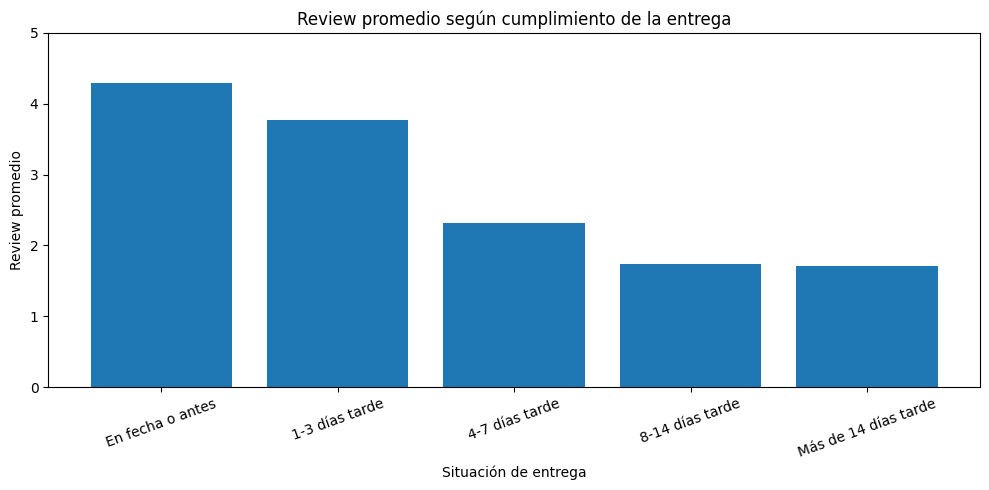

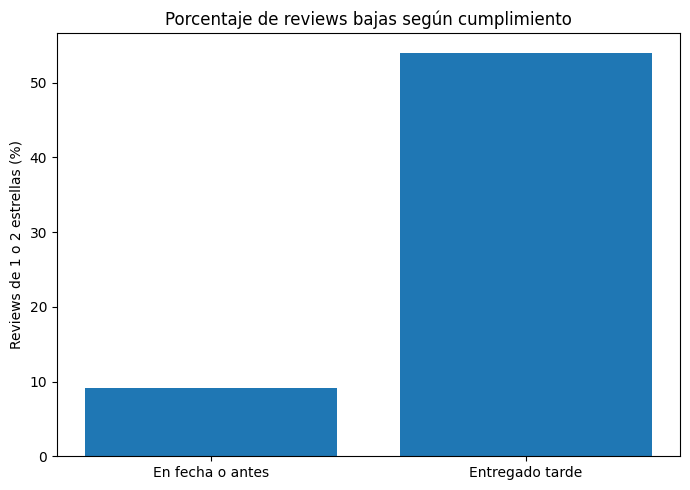

In [25]:
review_delivery = delivery_analysis[
    delivery_analysis["review_score_mean"].notna()
].copy()

print(
    "Pedidos válidos para análisis logística + reviews:",
    review_delivery.shape[0]
)

review_delivery["delivery_status"] = review_delivery[
    "delivery_delay_days"
].apply(
    lambda x: "Entregado tarde" if x > 0 else "En fecha o antes"
)

review_by_delivery = (
    review_delivery
    .groupby("delivery_status")
    .agg(
        orders=("order_id", "nunique"),
        average_review=("review_score_mean", "mean"),
        median_review=("review_score_mean", "median")
    )
    .reset_index()
)

print("Análisis de reviews por cumplimiento de fecha de entrega:", review_by_delivery)
review_delivery["low_review"] = (
    review_delivery["review_score_mean"] <= 2
)
low_review_analysis = (
    review_delivery
    .groupby("delivery_status")
    .agg(
        orders=("order_id", "count"),
        low_reviews=("low_review", "sum"),
        low_review_pct=("low_review", "mean")
    )
    .reset_index()
)

low_review_analysis["low_review_pct"] *= 100

print("Análisis de reviews bajas por cumplimiento de fecha de entrega:", low_review_analysis)

print("Correlación entre retraso de entrega y puntuación de review:", review_delivery[
    [
        "delivery_delay_days",
        "review_score_mean"
    ]
].corr())

def delay_group(days):
    if days <= 0:
        return "En fecha o antes"
    elif days <= 3:
        return "1-3 días tarde"
    elif days <= 7:
        return "4-7 días tarde"
    elif days <= 14:
        return "8-14 días tarde"
    else:
        return "Más de 14 días tarde"


review_delivery["delay_group"] = (
    review_delivery["delivery_delay_days"]
    .apply(delay_group)
)

delay_review_analysis = (
    review_delivery
    .groupby("delay_group")
    .agg(
        orders=("order_id", "count"),
        average_review=("review_score_mean", "mean")
    )
    .reset_index()
)

delay_order = [
    "En fecha o antes",
    "1-3 días tarde",
    "4-7 días tarde",
    "8-14 días tarde",
    "Más de 14 días tarde"
]

delay_review_analysis["delay_group"] = pd.Categorical(
    delay_review_analysis["delay_group"],
    categories=delay_order,
    ordered=True
)

delay_review_analysis = (
    delay_review_analysis
    .sort_values("delay_group")
)

print("Análisis de reviews por grupo de retraso en la entrega:", delay_review_analysis)

plt.figure(figsize=(10, 5))

plt.bar(
    delay_review_analysis["delay_group"].astype(str),
    delay_review_analysis["average_review"]
)

plt.title("Review promedio según cumplimiento de la entrega")
plt.xlabel("Situación de entrega")
plt.ylabel("Review promedio")

plt.ylim(0, 5)
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))

plt.bar(
    low_review_analysis["delivery_status"],
    low_review_analysis["low_review_pct"]
)

plt.title("Porcentaje de reviews bajas según cumplimiento")
plt.ylabel("Reviews de 1 o 2 estrellas (%)")

plt.tight_layout()
plt.show()

In [27]:
correlation_matrix = review_delivery[
    [
        "delivery_delay_days",
        "delivery_time_days",
        "review_score_mean",
        "payment_value",
        "freight_value",
        "items_count"
    ]
].corr()

correlation_matrix

correlation_matrix.style.background_gradient(
    cmap="coolwarm",
    vmin=-1,
    vmax=1
).format("{:.2f}")

,delivery_delay_days,delivery_time_days,review_score_mean,payment_value,freight_value,items_count
delivery_delay_days,1.00,0.60,-0.27,-0.02,-0.05,-0.03
delivery_time_days,0.60,1.00,-0.33,0.07,0.17,-0.02
review_score_mean,-0.27,-0.33,1.00,-0.04,-0.09,-0.12
payment_value,-0.02,0.07,-0.04,1.00,0.49,0.19
freight_value,-0.05,0.17,-0.09,0.49,1.00,0.44
items_count,-0.03,-0.02,-0.12,0.19,0.44,1.00


### Hallazgos sobre logística y satisfacción del cliente

Se analizaron 95.824 pedidos que cuentan simultáneamente con información válida de entrega y puntuación de review.

Los resultados muestran una relación clara entre el cumplimiento logístico y la satisfacción del cliente.

Los pedidos entregados en la fecha estimada o antes presentan una puntuación promedio de aproximadamente 4,29 sobre 5, mientras que los pedidos entregados tarde presentan una puntuación promedio de aproximadamente 2,57.

La diferencia también se observa en la proporción de reviews bajas (1 o 2 estrellas):

- En fecha o antes: 9,19%.
- Entregados tarde: 53,99%.

Esto significa que más de la mitad de los pedidos entregados tarde recibieron una valoración baja, frente a menos del 10% de aquellos entregados dentro del plazo.

Al analizar la magnitud del retraso se observa una caída progresiva de la puntuación promedio:

- En fecha o antes: 4,29.
- 1 a 3 días tarde: 3,77.
- 4 a 7 días tarde: 2,32.
- 8 a 14 días tarde: 1,75.
- Más de 14 días tarde: 1,71.

También se calculó la correlación entre `delivery_delay_days` y `review_score_mean`, obteniéndose aproximadamente -0,267.

El signo negativo indica que ambas variables tienden a moverse en direcciones opuestas: a medida que aumenta el retraso, la puntuación de la review tiende a disminuir. La relación no es perfecta ni implica causalidad, ya que la satisfacción del cliente también puede depender de factores como el producto, el vendedor, el precio o la atención recibida.

Sin embargo, la combinación de la correlación negativa, la diferencia de puntuaciones promedio y el fuerte aumento de reviews bajas evidencia una asociación relevante entre retrasos logísticos y menor satisfacción del cliente.

In [26]:
orders.to_csv(
    "../data/processed/orders_analysis.csv",
    index=False
)

items.to_csv(
    "../data/processed/order_items_analysis.csv",
    index=False
)

customers.to_csv(
    "../data/processed/customer_analysis.csv",
    index=False
)